# HR Employee Attrition Analysis (Compensation Attrition Analysis)

**Tujuan notebook ini:** menjawab business question ke-3: Apakah kompensasi (monthly income, salary hike, stock option) berbeda antara karyawan yang keluar vs bertahan?

## 1. Setup & Load Data

Load data langsung dari MySQL supaya konsisten dengan sumber data yang sudah dinormalisasi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

load_dotenv()

host = os.environ.get("DB_HOST")
user = os.environ.get("DB_USER")
password = os.environ.get("DB_PASSWORD")
database = os.environ.get("DB_NAME")

url_connect = f"mysql+pymysql://{user}:{password}@{host}/{database}"

engine = create_engine(url_connect)

In [2]:
query = """ SELECT
                e.attrition,
                c.monthly_income,
                c.percent_salary_hike,
                c.stock_option_level
            FROM employees e
            JOIN compensation c ON e.employee_id = c.employee_id"""

with engine.connect() as koneksi:
    df = pd.read_sql(query, con=koneksi)

In [3]:
print(f"Jumlah baris & kolom: {df.shape}")
df.head()

Jumlah baris & kolom: (1470, 4)


,attrition,monthly_income,percent_salary_hike,stock_option_level
0,Yes,5993,11,0
1,No,5130,23,1
2,Yes,2090,15,0
3,No,2909,11,0
4,No,3468,12,1


## 2. Analisis Deskriptif

Lakukan analisis deskriptif sederhana untuk mengetahui hubungan antara compensation (`monthly_income`, `percent_salary_hike`, `stock_option_level`) terhadap attrition.

In [4]:
compensation_attrition_rate = df.groupby('attrition').agg(['mean', 'median'])
compensation_attrition_rate = compensation_attrition_rate.round(2)
compensation_attrition_rate

monthly_income         percent_salary_hike         \
                    mean  median                mean median   
attrition                                                     
No               6832.74  5204.0               15.23   14.0   
Yes              4787.09  3202.0               15.10   14.0   

          stock_option_level         
                        mean median  
attrition                            
No                      0.85    1.0  
Yes                     0.53    0.0

Secara rata-rata maupun median, karyawan yang keluar (`attrition = Yes`) memiliki `monthly_income` yang lebih rendah (median 3.202) dibanding yang bertahan (median 5.204). Pola serupa juga terlihat pada `stock_option_level` (median 0 vs 1), sementara `percent_salary_hike` terlihat hampir identik di kedua kelompok (median 14 vs 14). Untuk memastikan apakah perbedaan-perbedaan ini signifikan secara statistik, perlu dilanjutkan ke uji Mann-Whitney U di bagian berikutnya — namun sebelum itu, perlu dicek dulu bentuk distribusi datanya.

### Pengelompokan Data Berdasarkan Attrition

Selanjutnya, bagi data untuk dikelompokan berdasarkan attrition, sebagai persiapan untuk uji distribusi, deteksi outlier, dan uji statistik di tahap berikutnya.

In [5]:
# Semua data tanpa kolom attrition
compensation_col = df.drop('attrition', axis=1)
print(f"Jumlah baris & kolom tanpa kolom attrition: {compensation_col.shape}")

# Mengelompokan semua data di tiap kolom dengan attrition Yes
attrition_yes = df.loc[
    df['attrition'] == 'Yes', 
    ['monthly_income', 'percent_salary_hike', 'stock_option_level']]
print(f"Jumlah baris & kolom kelompok attrition_yes: {attrition_yes.shape}")

# Mengelompokan semua data di tiap kolom dengan attrition No
attrition_no = df.loc[
    df['attrition'] == 'No', 
    ['monthly_income', 'percent_salary_hike', 'stock_option_level']]
print(f"Jumlah baris & kolom kelompok attrition_no: {attrition_no.shape}")

Jumlah baris & kolom tanpa kolom attrition: (1470, 3)
Jumlah baris & kolom kelompok attrition_yes: (237, 3)
Jumlah baris & kolom kelompok attrition_no: (1233, 3)


### Distribusi Data & Skewness

Lakukan visualisasi sederhana untuk melihat distribusi data & skewness-nya berdasarkan kelompok attrition_yes dan attrition_no, sekaligus mengecek apakah data cukup normal untuk menentukan uji statistik yang tepat.

Skewness kelompok attrition_yes kolom monthly_income: 1.91
Skewness kelompok attrition_no kolom monthly_income: 1.28
Skewness kelompok attrition_yes kolom percent_salary_hike: 0.85
Skewness kelompok attrition_no kolom percent_salary_hike: 0.81
Skewness kelompok attrition_yes kolom stock_option_level: 1.68
Skewness kelompok attrition_no kolom stock_option_level: 0.87


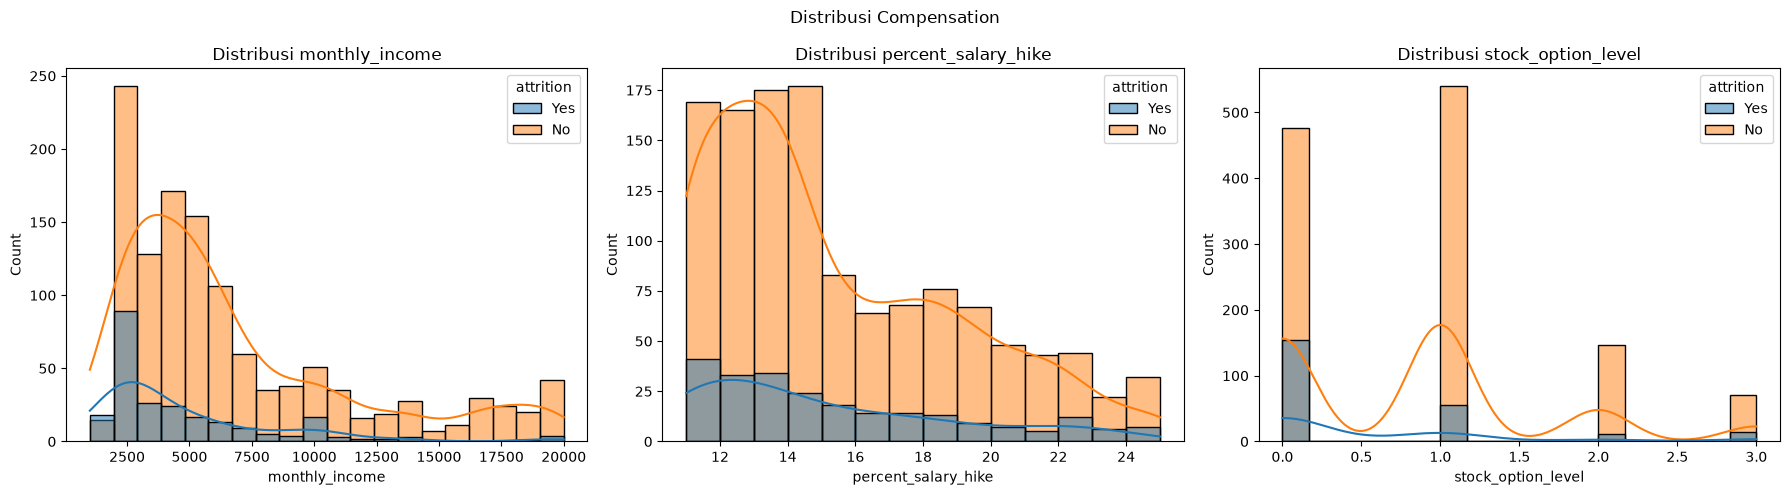

In [6]:
from scipy.stats import skew

n = len(compensation_col.columns)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))

for ax, column in zip(axes, compensation_col.columns):
    print(f"Skewness kelompok attrition_yes kolom {column}: {skew(attrition_yes[column]).round(2)}")
    print(f"Skewness kelompok attrition_no kolom {column}: {skew(attrition_no[column]).round(2)}")
    sns.histplot(df, x=df[column], hue='attrition', ax=ax, kde=True)
    ax.set_title(f"Distribusi {column}")

plt.suptitle("Distribusi Compensation")
plt.tight_layout()
plt.show()

Diperhatikan bahwa, seluruh kolom menunjukkan nilai skewness **positif** (>0) di kedua kelompok, dengan `monthly_income` paling menjulur ke kanan (skewness 1,91 pada attrition_yes, 1,28 pada attrition_no). Ini mengindikasikan data tidak berdistribusi normal, sehingga uji non-parametrik (Mann-Whitney U) menjadi pilihan yang tepat untuk ketiga variabel.

### Outlier

Membuat fungsi outliers untuk mengetahui jumlah outlier di tiap kolom pada masing-masing kelompok, menggunakan metode **IQR** dengan Q1/Q3 dihitung dari keseluruhan data (global) — bukan masing-masing subset — supaya kedua kelompok dibandingkan dengan standar ambang batas yang sama.

In [7]:
def outliers(df1):
    for column in df1.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
    
        batas_bawah = Q1 - IQR * 1.5
        batas_atas = Q3 + IQR * 1.5

        outlier = df1.loc[
            (df1[column] < batas_bawah) | (df1[column] > batas_atas), 
            column]
        print(f"Jumlah outlier di kolom {column} adalah {len(outlier)}")

### Outlier Kelompok Attrition Yes

In [8]:
outliers(attrition_yes)

Jumlah outlier di kolom monthly_income adalah 5
Jumlah outlier di kolom percent_salary_hike adalah 0
Jumlah outlier di kolom stock_option_level adalah 15


Dalam kelompok attrition_yes, terdapat 5 outlier di kolom `monthly_income` dan 15 outlier di kolom `stock_option_level`. Sementara itu, kolom `percent_salary_hike` tidak memiliki outlier sama sekali.

### Outlier Kelompok Attrition No

In [9]:
outliers(attrition_no)

Jumlah outlier di kolom monthly_income adalah 109
Jumlah outlier di kolom percent_salary_hike adalah 0
Jumlah outlier di kolom stock_option_level adalah 70


Dalam kelompok attrition_no, terdapat 109 outlier di kolom `monthly_income` dan 70 outlier di kolom `stock_option_level`. Sementara itu, kolom `percent_salary_hike` tidak memiliki outlier sama sekali.

Terdapat total **114 outlier** di kolom `monthly_income` *(5 di kelompok attrition_yes, 109 di kelompok attrition_no)* dan **85 outlier** di kolom `stock_option_level` *(15 di kelompok attrition_yes, 70 di kelompok attrition_no)*. Secara proporsi terhadap ukuran masing-masing kelompok, outlier `monthly_income` lebih terkonsentrasi di attrition_no *(8,8% vs 2,1%)*, sementara outlier `stock_option_level` justru sedikit lebih terkonsentrasi di attrition_yes *(6,3% vs 5,7%)*. Sementara itu, kolom `percent_salary_hike` **tidak memiliki outlier** sama sekali.

## 3. Uji Statistik & Effect Size

Menguji tingkat asosiasi antara 2 kelompok kategorikal terhadap 1 variabel numerik (`monthly_income`, `percent_salary_hike`, `stock_option_level`) menggunakan **Mann-Whitney U test** dan **rank-biserial correlation** sebagai effect size.

In [10]:
def mann_whitney(df1, df2):
    mwu, p_value = stats.mannwhitneyu(df1, df2)
    hasil_mwu = f"Nilai statistik Mann-Whitney U test: {mwu}"
    if p_value < 0.0001:
        hasil_p_value = "P-value < 0.0001"
    else:
        hasil_p_value = f"P-value: {p_value:.4f}"
    return mwu, hasil_mwu, hasil_p_value

In [11]:
def rank_biserial(mwu, df1, df2):
    N1 = len(df1)
    N2 = len(df2)
    r_bs = 1 - (2 * mwu) / (N1 * N2)
    print(f"Nilai Rank-Biserial nya: {r_bs:.4f}")

### Terhadap `monthly_income`

In [12]:
mwu1, hasil_mwu1, p_value1 = mann_whitney(attrition_yes['monthly_income'], attrition_no['monthly_income'])
print(hasil_mwu1)
print(p_value1)

Nilai statistik Mann-Whitney U test: 100620.5
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `monthly_income`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [13]:
rank_biserial(mwu1, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.3113


Diperoleh nilai rank-biserial correlation-nya sebesar **0,3113** — ambang moderate (0,30) — menunjukkan kekuatan asosiasi yang mendekati **moderate**.

### Terhadap `percent_salary_hike`

In [14]:
mwu2, hasil_mwu2, p_value2 = mann_whitney(attrition_yes['percent_salary_hike'], attrition_no['percent_salary_hike'])
print(hasil_mwu2)
print(p_value2)

Nilai statistik Mann-Whitney U test: 140726.5
P-value: 0.3655


Nilai p-value 0,3655 — lebih dari 0,05 — menunjukkan **tidak terdapat asosiasi yang signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `percent_salary_hike`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [15]:
rank_biserial(mwu2, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.0368


Diperoleh nilai rank-biserial correlation-nya sebesar **0,0368** — jauh di bawah kategori lemah (0,10) — menunjukkan kekuatan asosiasi yang **sangat lemah**.

### Terhadap `stock_option_level`

In [16]:
mwu3, hasil_mwu3, p_value3 = mann_whitney(attrition_yes['stock_option_level'], attrition_no['stock_option_level'])
print(hasil_mwu3)
print(p_value3)

Nilai statistik Mann-Whitney U test: 109611.0
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `stock_option_level`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [17]:
rank_biserial(mwu3, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.2498


Diperoleh nilai rank-biserial correlation-nya sebesar **0,2498** — belum mencapai ambang moderate (0,30) — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

## 4. Visualisasi

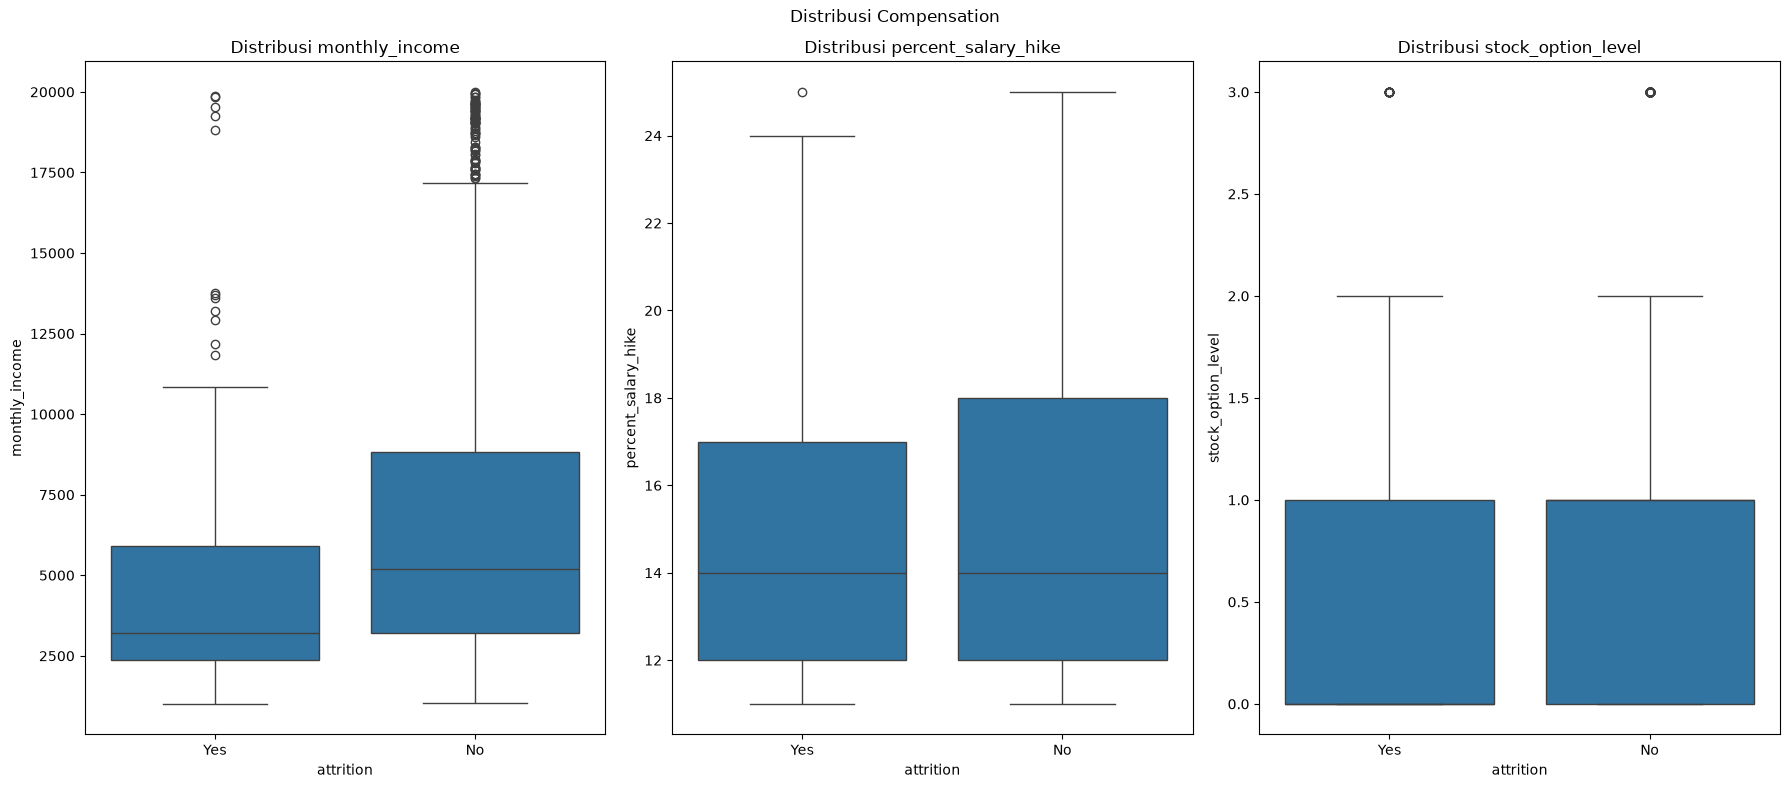

In [18]:
n = len(compensation_col.columns)
fig, axes = plt.subplots(1, n, figsize=(6*n, 8))

for ax, column in zip(axes, compensation_col.columns):
    sns.boxplot(data=df, x='attrition', y=column, ax=ax)
    ax.set_title(f"Distribusi {column}")

plt.suptitle("Distribusi Compensation")
plt.tight_layout()
plt.show()

**Notes:** titik-titik di boxplot ini adalah outlier *relatif terhadap grup masing-masing* (bawaan `sns.boxplot`), berbeda dari analisis outlier di section 2 yang menggunakan ambang batas global.

## Kesimpulan

Ketiga variabel kompensasi diuji menggunakan Mann-Whitney U test (uji non-parametrik, dipilih karena distribusi ketiganya skewed di kedua kelompok) untuk membandingkan karyawan yang keluar (`attrition = Yes`) dengan yang bertahan (`attrition = No`).

**Monthly Income** menunjukkan perbedaan yang signifikan secara statistik (U = 100.620,5; p < 0,0001). Karyawan yang keluar memiliki median monthly income yang jauh lebih rendah (3.202) dibanding yang bertahan (5.204) — hampir 39% lebih rendah. Rank-biserial correlation sebesar 0,3113 menunjukkan kekuatan asosiasi yang mendekati kategori **moderate** (ambang 0,30 menurut Cohen, 1988), menjadikan monthly income sebagai faktor kompensasi paling berpengaruh terhadap attrition di antara ketiga variabel yang diuji.

**Stock Option Level** juga menunjukkan perbedaan signifikan (U = 109.611,0; p < 0,0001), dengan median stock option karyawan yang keluar (0) lebih rendah dibanding yang bertahan (1). Rank-biserial correlation sebesar 0,2498 menunjukkan asosiasi **lemah hingga sedang** — cukup berarti, meski tidak sekuat monthly income.

**Percent Salary Hike** tidak menunjukkan perbedaan yang signifikan (U = 140.726,5; p = 0,3655), dengan median yang identik di kedua kelompok (14%). Rank-biserial correlation sebesar 0,0368 mengonfirmasi bahwa persentase kenaikan gaji **hampir tidak berasosiasi** dengan keputusan karyawan untuk keluar — artinya seberapa besar kenaikan gaji tahunan yang diterima bukan faktor pembeda antara karyawan yang bertahan dan yang keluar.

**Catatan batasan**: seperti pada analisis overtime (Q2), hasil ini menunjukkan asosiasi, bukan hubungan sebab-akibat, karena sifat data yang cross-sectional. Perlu diingat pula bahwa monthly income dan stock option level kemungkinan besar berkorelasi dengan job level (karyawan level lebih tinggi cenderung memiliki keduanya lebih besar) — sehingga efek yang teramati di sini bisa jadi sebagian mencerminkan pengaruh job level, bukan murni kompensasi itu sendiri. Ini pertanyaan yang relevan untuk didalami di business question berikutnya (Q4: tenure & stagnasi karier).

**Implikasi praktis**: dari ketiga aspek kompensasi, **monthly income** adalah yang paling layak menjadi perhatian utama HR — kesenjangan pendapatan yang cukup besar antara karyawan yang bertahan dan yang keluar mengindikasikan bahwa kompensasi dasar berperan lebih besar terhadap retensi dibanding besaran kenaikan gaji tahunan atau kepemilikan stock option.